In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ghqSrqFLA6WCAFrojYHF")
project = rf.workspace("volleyballyolo").project("volleyballyolo")
version = project.version(1)
dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 83.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to VolleyBallYolo-1 in yolov11:: 100%|██████████| 622/622 [00:00<00:00, 6123.42it/s]


In [2]:
!pip install --upgrade pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0


In [3]:
# Gemma 4 instalation

%%capture
import os, re
import torch

v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
os.system("pip install sentencepiece protobuf 'datasets==4.3.0' 'huggingface_hub>=0.34.0' hf_transfer")
os.system(f"pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth")
os.system("pip install --no-deps --upgrade 'torchao>=0.16.0'")
os.system("pip install --no-deps transformers==5.5.0 'tokenizers>=0.22.0,<=0.23.0'")
os.system("pip install --no-deps --upgrade timm")
torch._dynamo.config.recompile_limit = 64

In [4]:
# Load the Gemma 4 model
# run EACH TIME when re-opening the colab

from unsloth import FastModel

gemma_model, gemma_tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-4-E2B-it",
    dtype = None,
    max_seq_length = 1024,
    load_in_4bit = True,  # 4bit to save memory with everything else
    full_finetuning = False,
)
print("Gemma 4 loaded correctly")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json:   0%|          | 0.00/301k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/203 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/16.8k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/19.9k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

✅ Gemma 4 cargado correctamente


In [5]:
!find /content -name "data.yaml"

/content/VolleyBallYolo-1/data.yaml


In [6]:
!cat /content/VolleyBallYolo-1/data.yaml


train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['ball', 'person']

roboflow:
  workspace: volleyballyolo
  project: volleyballyolo
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/volleyballyolo/volleyballyolo/dataset/1

In [7]:
# Install ultralytics (YOLO)
!pip install ultralytics

from ultralytics import YOLO
import yaml

# see how many images there are per split
!find /content/VolleyBallYolo-1/train/images -name "*.jpg" | wc -l
!find /content/VolleyBallYolo-1/valid/images -name "*.jpg" | wc -l
!find /content/VolleyBallYolo-1/test/images -name "*.jpg" | wc -l

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
267
25
13


In [8]:
from ultralytics import YOLO

# load YOLO pretrained (transfer learning)
model = YOLO("yolo11n.pt")

# training
results = model.train(
    data="/content/VolleyBallYolo-1/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="volleyball_detector",
    pretrained=True
)

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/VolleyBallYolo-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=volleyball_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# Downloading models y data from the shared Drive
# CRUCIAL IF NOT LABELING IMAGES
from google.colab import drive
drive.mount('/content/drive')

!pip install gdown
import gdown
import os

os.makedirs("/content/drive/MyDrive/volleyball_mlp", exist_ok=True)
os.makedirs("/content/runs/detect/volleyball_detector/weights", exist_ok=True)

print("Descargando modelos...")

gdown.download("https://drive.google.com/uc?id=1_FBk4T_IRATYDxi9PD2PKf7epyhRCC7X",
               "/content/runs/detect/volleyball_detector/weights/best.pt", quiet=False)

gdown.download("https://drive.google.com/uc?id=1tkLy4e4xO2mNg8ByQ4ttL1xwBniF-c3r",
               "/content/drive/MyDrive/volleyball_mlp/lstm_trajectory.pt", quiet=False)

gdown.download("https://drive.google.com/uc?id=1NYmCucoyW8rgO9Ygv-Mkz3m3mWAvkbXX",
               "/content/drive/MyDrive/volleyball_mlp/mlp_team_classifier.pt", quiet=False)

gdown.download("https://drive.google.com/uc?id=1W3ZZF7pziPW3XGvghusSGcSD17nkJ38A",
               "/content/drive/MyDrive/volleyball_mlp/person_labels.json", quiet=False)

gdown.download("https://drive.google.com/uc?id=1BiOySmk8zS0WD6NL8Ev3m4yMvOz_Om3X",
               "/content/drive/MyDrive/volleyball_mlp/trajectories.json", quiet=False)

gdown.download("https://drive.google.com/uc?id=11fAV1qe2ba5xD0NUIXl2Py-6T621VjfC",
               "/content/drive/MyDrive/volleyball_mlp/volleyball_video.mp4", quiet=False)

print("All of the files loaded correctly")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Descargando modelos...


Downloading...
From: https://drive.google.com/uc?id=1_FBk4T_IRATYDxi9PD2PKf7epyhRCC7X
To: /content/runs/detect/volleyball_detector/weights/best.pt
100%|██████████| 5.47M/5.47M [00:00<00:00, 17.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tkLy4e4xO2mNg8ByQ4ttL1xwBniF-c3r
To: /content/drive/MyDrive/volleyball_mlp/lstm_trajectory.pt
100%|██████████| 216k/216k [00:00<00:00, 5.56MB/s]
Downloading...
From: https://drive.google.com/uc?id=1NYmCucoyW8rgO9Ygv-Mkz3m3mWAvkbXX
To: /content/drive/MyDrive/volleyball_mlp/mlp_team_classifier.pt
100%|██████████| 6.12k/6.12k [00:00<00:00, 21.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1W3ZZF7pziPW3XGvghusSGcSD17nkJ38A
To: /content/drive/MyDrive/volleyball_mlp/person_labels.json
100%|██████████| 58.0k/58.0k [00:00<00:00, 4.86MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BiOySmk8zS0WD6NL8Ev3m4yMvOz_Om3X
To: /content/drive/MyDrive/volleyball_mlp/trajectories.json
100%|██████████| 39.7k/39.7k [00:00<00:00, 51.1MB/s]

✅ Todos los archivos descargados correctamente



image 1/13 /content/VolleyBallYolo-1/test/images/13_jpg.rf.82a2784d71edd80f50a624772fd606b3.jpg: 640x640 1 ball, 7 persons, 38.4ms
image 2/13 /content/VolleyBallYolo-1/test/images/159_png.rf.878a89205b8699c80fe4270b119f21fc.jpg: 640x640 15 persons, 17.0ms
image 3/13 /content/VolleyBallYolo-1/test/images/304_png.rf.d8cf9b5a25e214f40ed004a7d3c80ec2.jpg: 640x640 1 ball, 13 persons, 16.8ms
image 4/13 /content/VolleyBallYolo-1/test/images/32_jpg.rf.60036f321bb0f9125e0469176ad36642.jpg: 640x640 1 ball, 12 persons, 16.5ms
image 5/13 /content/VolleyBallYolo-1/test/images/484_png.rf.a8b1e3589f1f1b2bafa03fd40ba75586.jpg: 640x640 15 persons, 16.3ms
image 6/13 /content/VolleyBallYolo-1/test/images/486_png.rf.d2bb575e1df122ecff814c3e503ae9af.jpg: 640x640 11 persons, 18.6ms
image 7/13 /content/VolleyBallYolo-1/test/images/509_png.rf.66c31a1323ff708de2f4da74731c277e.jpg: 640x640 13 persons, 18.4ms
image 8/13 /content/VolleyBallYolo-1/test/images/518_png.rf.425590d2720dd212ada0431d83f83d81.jpg: 640x6

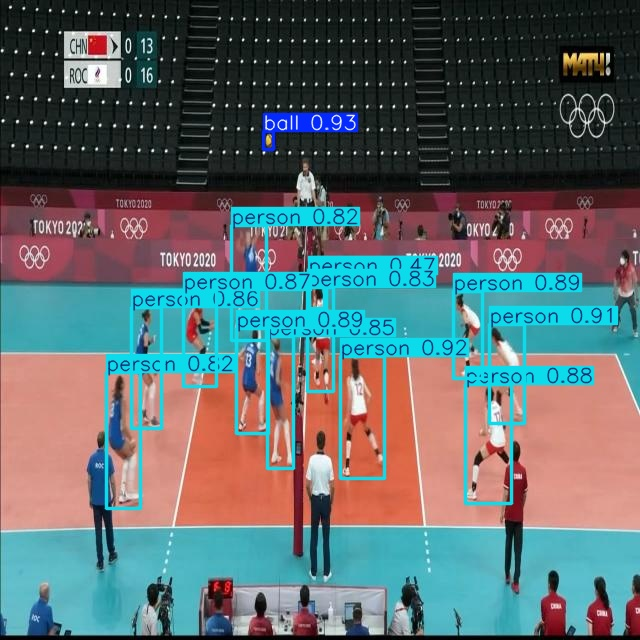

In [11]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load the best trained model
model = YOLO("/content/runs/detect/volleyball_detector/weights/best.pt")

# inference over test images
results = model.predict(
    source="/content/VolleyBallYolo-1/test/images",
    conf=0.3,
    save=True,
    name="test_predictions"
)

# show one image with the predictions
import glob
imgs = glob.glob("/content/runs/detect/test_predictions/*.jpg")
img = cv2.imread(imgs[0])
cv2_imshow(img)

In [12]:
import os
print(os.path.exists("/content/VolleyBallYolo-1/data.yaml"))
print(os.path.exists("/content/runs/detect/volleyball_detector/weights/best.pt"))

True
True


MLP

In [13]:
# MLP - set up Drive
# CRUCIAL IF NOT LABELING IMAGES
from google.colab import drive
import os

drive.mount("/content/drive")

DRIVE_DIR = "/content/drive/MyDrive/volleyball_mlp"
os.makedirs(DRIVE_DIR, exist_ok=True)
print("Drive set up correctly")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive montado


In [14]:
# MLP - Extract detections and tool for labeling
# DONT RUN IF NOT LABELING

from google.colab import files
import cv2, os, shutil, glob, json
import numpy as np
from ultralytics import YOLO
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
import io

# Upload video
print("Upload your volleyball video:")
uploaded = files.upload()
video_filename = list(uploaded.keys())[0]
video_local = f"/content/{video_filename}"
shutil.copy(video_local, f"{DRIVE_DIR}/volleyball_video.mp4")
print("Video saved to Drive")

# Find YOLO
candidates = glob.glob("/content/runs/detect/volleyball_detector*/weights/best.pt")
if not candidates:
    raise RuntimeError("best.pt not found — train YOLO first")
yolo = YOLO(candidates[-1])

# Extract crops from each detected person
CROPS_DIR = "/content/person_crops"
LABELS_PATH = "/content/person_labels.json"

# Clean old crops
if os.path.exists(CROPS_DIR):
    shutil.rmtree(CROPS_DIR)

# Clean old labels
if os.path.exists(LABELS_PATH):
    os.remove(LABELS_PATH)

os.makedirs(CROPS_DIR, exist_ok=True)

cap = cv2.VideoCapture(video_local)
detections = []
crop_idx = 0
frame_idx = 0
FRAME_STEP = 10

print("Extracting detected people...")
while True:
    ret, frame = cap.read()
    if not ret:
        break
    if frame_idx % FRAME_STEP != 0:
        frame_idx += 1
        continue
    frame_idx += 1

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = yolo.predict(frame_rgb, conf=0.2, verbose=False)
    h, w = frame.shape[:2]

    for box in results[0].boxes:
        class_id = int(box.cls[0])
        class_name = yolo.names[class_id]

        if class_name != "person":
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)

        crop = frame_rgb[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        crop_path = f"{CROPS_DIR}/crop_{crop_idx:04d}.jpg"
        Image.fromarray(crop).save(crop_path)

        cx = (x1 + x2) / 2 / w
        cy = (y1 + y2) / 2 / h
        bw = (x2 - x1) / w
        bh = (y2 - y1) / h

        detections.append({
            "crop": crop_path,
            "features": [cx, cy, bw, bh]
        })
        crop_idx += 1

cap.release()
print(f"{crop_idx} people detected")
print("Now label each crop: Team 1 or Team 2")

Sube tu vídeo de voleibol:


KeyboardInterrupt: 

In [ ]:
# MLP - Labeling
# DONT RUN IF NOT LABELING
# ONLY RUN ONCE IF LABELING

crop_files = sorted(glob.glob("/content/person_crops/*.jpg"))
labels = {}
current_idx = [0]

img_widget  = widgets.Image(width=300)
info_label  = widgets.HTML(value="")
btn_team1   = widgets.Button(description="TEAM 1", button_style="primary", layout=widgets.Layout(width="160px"))
btn_team1.style.button_color = "black" # just so it's more intuitive for whoever labels the images
btn_team2   = widgets.Button(description="TEAM 2", button_style="danger",  layout=widgets.Layout(width="160px"))
btn_back    = widgets.Button(description="← Back",                          layout=widgets.Layout(width="120px"))

def show_crop():
    if current_idx[0] >= len(crop_files):
        info_label.value = "<h3>Labeling completed!</h3>"
        with open("/content/person_labels.json", "w") as f:
            json.dump({"labels": labels, "detections": detections}, f)
        shutil.copy("/content/person_labels.json", f"{DRIVE_DIR}/person_labels.json")
        info_label.value += f"<p>{len(labels)} labels saved to Drive</p>"
        return

    fname = crop_files[current_idx[0]]
    basename = os.path.basename(fname)

    img = Image.open(fname).resize((300, 300))
    buf = io.BytesIO()
    img.save(buf, format="JPEG")
    img_widget.value = buf.getvalue()

    ya = labels.get(basename, "not labeled")
    info_label.value = f"<b>Crop {current_idx[0]+1}/{len(crop_files)}</b> → current label: <b>{ya}</b>"

def on_team1(b):
    labels[os.path.basename(crop_files[current_idx[0]])] = 1  # 1 = Team 1
    current_idx[0] += 1
    show_crop()

def on_team2(b):
    labels[os.path.basename(crop_files[current_idx[0]])] = 0  # 0 = Team 2
    current_idx[0] += 1
    show_crop()

def on_back(b):
    if current_idx[0] > 0:
        current_idx[0] -= 1
        show_crop()

btn_team1.on_click(on_team1)
btn_team2.on_click(on_team2)
btn_back.on_click(on_back)

display(info_label, img_widget,
        widgets.HBox([btn_team1, btn_team2, btn_back]))
show_crop()

In [15]:
import os
path = "/content/drive/MyDrive/volleyball_mlp/person_labels.json"
print(f"Exists: {os.path.exists(path)}")
print(f"Size: {os.path.getsize(path)} bytes")

Existe: True
Tamaño: 58031 bytes


In [16]:
# MLP - train with Pytorch
# ONLY RUN ONCE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json, shutil
import numpy as np

with open(f"{DRIVE_DIR}/person_labels.json") as f:
    data = json.load(f)

stored_labels     = data["labels"]
stored_detections = data["detections"]

X, y = [], []
for det in stored_detections:
    basename = os.path.basename(det["crop"])
    if basename not in stored_labels:
        continue
    X.append(det["features"])  # [cx, cy, bw, bh]
    y.append(stored_labels[basename])

X = torch.tensor(np.array(X), dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

print(f"Dataset: {len(X)} detections")
print(f"  Team 1: {y.sum().item()}")
print(f"  Team 2: {len(y) - y.sum().item()}")

split        = int(0.8 * len(X))
train_loader = DataLoader(TensorDataset(X[:split], y[:split]), batch_size=16, shuffle=True)
val_loader   = DataLoader(TensorDataset(X[split:],  y[split:]),  batch_size=16)

class TeamClassifierMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )
    def forward(self, x):
        return self.net(x)

mlp_team  = TeamClassifierMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_team.parameters(), lr=0.001)

print("\nTraining MLP...")
for epoch in range(50):
    mlp_team.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(mlp_team(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        mlp_team.eval()
        correct = sum(
            (mlp_team(xb).argmax(1) == yb).sum().item()
            for xb, yb in val_loader
        )
        acc = correct / max(len(X[split:]), 1) * 100
        print(f"Epoch {epoch+1}/50 | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {acc:.1f}%")

torch.save(mlp_team.state_dict(), "/content/mlp_team_classifier.pt")
shutil.copy("/content/mlp_team_classifier.pt", f"{DRIVE_DIR}/mlp_team_classifier.pt")
print("\nMLP saved to Drive")

Dataset: 368 detecciones
  Equipo 1: 183
  Equipo 2: 185

Entrenando MLP...
Epoch 10/50 | Loss: 0.4938 | Val Acc: 73.0%
Epoch 20/50 | Loss: 0.2609 | Val Acc: 73.0%
Epoch 30/50 | Loss: 0.2416 | Val Acc: 73.0%
Epoch 40/50 | Loss: 0.2260 | Val Acc: 73.0%
Epoch 50/50 | Loss: 0.2452 | Val Acc: 74.3%

✅ MLP guardado en Drive


In [17]:
# MLP - load model from drive
# run EACH TIME when re-opening the colab

import torch
import torch.nn as nn
import shutil, os

class TeamClassifierMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )
    def forward(self, x):
        return self.net(x)

if not os.path.exists("/content/mlp_team_classifier.pt"):
    shutil.copy(f"{DRIVE_DIR}/mlp_team_classifier.pt",
                "/content/mlp_team_classifier.pt")

mlp_team = TeamClassifierMLP()
mlp_team.load_state_dict(torch.load(
    "/content/mlp_team_classifier.pt", map_location="cpu"))
mlp_team.eval()
print("MLP loaded correctly")

✅ MLP cargado correctamente


RNN

In [18]:
# RNN - Extract trajectories from the video
# ONLY RUN THE FIRST TIME

import cv2
import numpy as np
import json
import glob
from ultralytics import YOLO

candidates = glob.glob("/content/runs/detect/volleyball_detector*/weights/best.pt")
yolo = YOLO(candidates[-1])

video_local = f"{DRIVE_DIR}/volleyball_video.mp4"
cap = cv2.VideoCapture(video_local)

FRAME_STEP   = 3   # every 3 frames for smoother trajectories
MAX_DIST     = 0.1 # maximum normalized distance to connect detections

frame_idx    = 0
all_tracks   = {}  # track_id -> list of (cx, cy)
active_tracks = {} # track_id -> last position
next_id      = 0

print("Extracting trajectories...")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    if frame_idx % FRAME_STEP != 0:
        frame_idx += 1
        continue
    frame_idx += 1

    h, w = frame.shape[:2]
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = yolo.predict(frame_rgb, conf=0.3, verbose=False)

    detections = []
    for box in results[0].boxes:
        if yolo.names[int(box.cls[0])] != "person":
            continue
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cx = (x1 + x2) / 2 / w
        cy = (y1 + y2) / 2 / h
        detections.append((cx, cy))

    # Connect detections with active tracks using minimum distance
    matched_tracks = set()
    matched_dets   = set()

    for tid, last_pos in active_tracks.items():
        best_dist = MAX_DIST
        best_det  = None
        for i, det in enumerate(detections):
            if i in matched_dets:
                continue
            dist = np.sqrt((det[0] - last_pos[0])**2 + (det[1] - last_pos[1])**2)
            if dist < best_dist:
                best_dist = dist
                best_det  = i
        if best_det is not None:
            all_tracks[tid].append(detections[best_det])
            active_tracks[tid] = detections[best_det]
            matched_tracks.add(tid)
            matched_dets.add(best_det)

    # New unmatched detections → new track
    for i, det in enumerate(detections):
        if i not in matched_dets:
            all_tracks[next_id]    = [det]
            active_tracks[next_id] = det
            next_id += 1

    # Remove tracks not updated (player out of camera)
    active_tracks = {tid: pos for tid, pos in active_tracks.items()
                     if all_tracks[tid][-1] == pos}

cap.release()

# Keep only trajectories with enough points
MIN_LENGTH = 15
trajectories = [seq for seq in all_tracks.values() if len(seq) >= MIN_LENGTH]
print(f"{len(trajectories)} trajectories extracted (min {MIN_LENGTH} frames)")

with open("/content/trajectories.json", "w") as f:
    json.dump(trajectories, f)
import shutil
shutil.copy("/content/trajectories.json", f"{DRIVE_DIR}/trajectories.json")
print("Trajectories saved to Drive")

Extrayendo trayectorias...
✅ 13 trayectorias extraídas (min 15 frames)
✅ Trayectorias guardadas en Drive


In [19]:
# RNN - Train LSTM trajectories
# ONLY RUN THE FIRST TIME

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json
import numpy as np
import shutil

with open("/content/trajectories.json") as f:
    trajectories = json.load(f)

SEQ_LEN = 10  # input frames
X, y = [], []

for traj in trajectories:
    traj = np.array(traj)
    for i in range(len(traj) - SEQ_LEN):
        X.append(traj[i:i+SEQ_LEN])       # last 10 frames
        y.append(traj[i+SEQ_LEN])         # next position

X = torch.tensor(np.array(X), dtype=torch.float32)  # (N, 10, 2)
y = torch.tensor(np.array(y), dtype=torch.float32)  # (N, 2)

print(f"Dataset: {len(X)} training sequences")

split        = int(0.8 * len(X))
train_loader = DataLoader(TensorDataset(X[:split], y[:split]), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X[split:],  y[split:]),  batch_size=32)

class TrajectoryLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=2, hidden_size=64, num_layers=2,
                            batch_first=True, dropout=0.2)
        self.fc   = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # last hidden state

lstm_model = TrajectoryLSTM()
criterion  = nn.MSELoss()
optimizer  = optim.Adam(lstm_model.parameters(), lr=0.001)

print("Training LSTM...")
for epoch in range(100):
    lstm_model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(lstm_model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 20 == 0:
        lstm_model.eval()
        val_loss = sum(
            criterion(lstm_model(xb), yb).item()
            for xb, yb in val_loader
        ) / len(val_loader)
        print(f"Epoch {epoch+1}/100 | Train Loss: {total_loss/len(train_loader):.6f} | Val Loss: {val_loss:.6f}")

torch.save(lstm_model.state_dict(), "/content/lstm_trajectory.pt")
shutil.copy("/content/lstm_trajectory.pt", f"{DRIVE_DIR}/lstm_trajectory.pt")
print("\nLSTM saved to Drive")

Dataset: 813 secuencias de entrenamiento
\Training LSTM...
Epoch 20/100 | Train Loss: 0.003210 | Val Loss: 0.002702
Epoch 40/100 | Train Loss: 0.002007 | Val Loss: 0.001454
Epoch 60/100 | Train Loss: 0.001492 | Val Loss: 0.001514
Epoch 80/100 | Train Loss: 0.001279 | Val Loss: 0.001759
Epoch 100/100 | Train Loss: 0.001156 | Val Loss: 0.001065

✅ LSTM guardada en Drive


In [20]:
# RNN - load LSTM from Drive
# run EACH TIME when re-opening the colab

import torch
import torch.nn as nn
import shutil, os

class TrajectoryLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=2, hidden_size=64, num_layers=2,
                            batch_first=True, dropout=0.2)
        self.fc   = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

if not os.path.exists("/content/lstm_trajectory.pt"):
    shutil.copy(f"{DRIVE_DIR}/lstm_trajectory.pt",
                "/content/lstm_trajectory.pt")

lstm_model = TrajectoryLSTM()
lstm_model.load_state_dict(torch.load(
    "/content/lstm_trajectory.pt", map_location="cpu"))
lstm_model.eval()
print("LSTM loaded correctly")

✅ LSTM cargada correctamente


In [21]:
import cv2
cap = cv2.VideoCapture(f"{DRIVE_DIR}/volleyball_video.mp4")
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
print(f"Resolution: {w}x{h}")

Resolución: 1920x1080


📊 MLP Statistics: Team classification

Validation — 74 samples
Accuracy:  74.3%

Detailed report:
              precision    recall  f1-score   support

      Team 2       0.63      1.00      0.77        32
      Team 1       1.00      0.55      0.71        42

    accuracy                           0.74        74
   macro avg       0.81      0.77      0.74        74
weighted avg       0.84      0.74      0.74        74



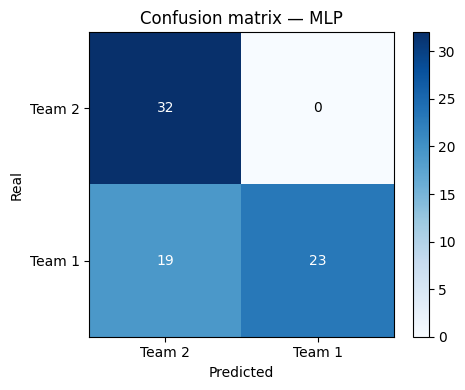


📊 LSTM Statistics: Trayectory predictions

Validation — 163 sequences
Video resolution: 1920x1080
MSE:               0.000936
Normalized MAE:    0.0243
MAE in pixels:     36.5 px
MAE percentage:    2.43% of the screen


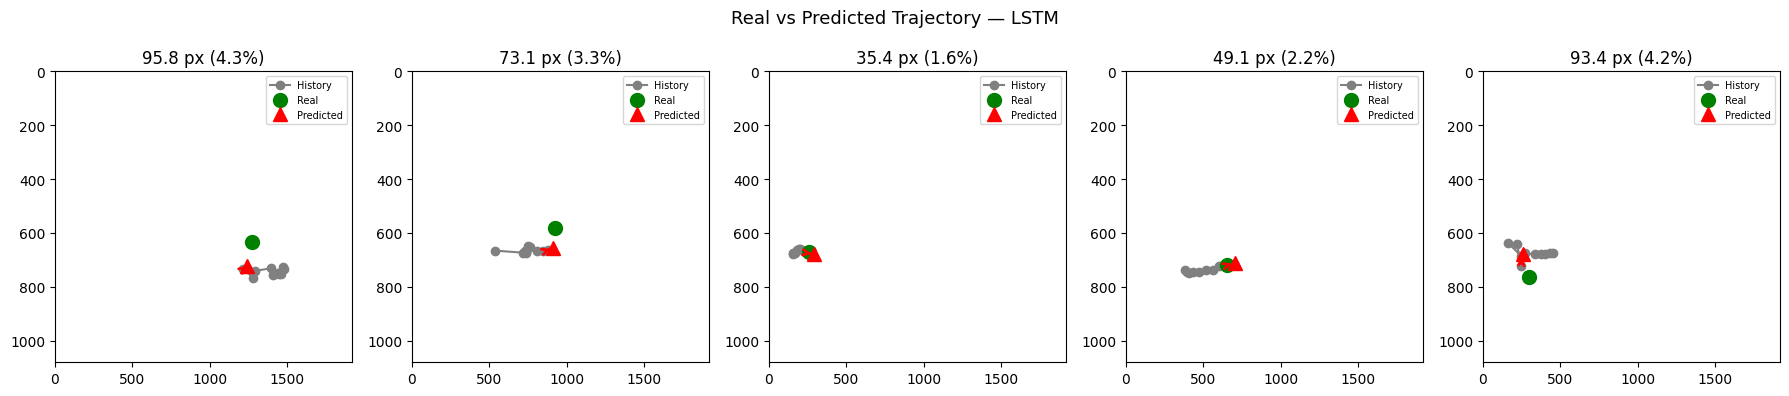


✅ Completed statistics


In [22]:
# MLP and LSTM statistics

import torch
import torch.nn as nn
import numpy as np
import json
import os
import shutil
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Retrieve files from Drive if not available locally
if not os.path.exists("/content/person_labels.json"):
    shutil.copy(f"{DRIVE_DIR}/person_labels.json", "/content/person_labels.json")
if not os.path.exists("/content/trajectories.json"):
    shutil.copy(f"{DRIVE_DIR}/trajectories.json", "/content/trajectories.json")

# MLP
print("MLP Statistics: Team classification\n")


with open("/content/person_labels.json") as f:
    data = json.load(f)

stored_labels     = data["labels"]
stored_detections = data["detections"]

X_mlp, y_mlp = [], []
for det in stored_detections:
    basename = os.path.basename(det["crop"])
    if basename not in stored_labels:
        continue
    X_mlp.append(det["features"])
    y_mlp.append(stored_labels[basename])

X_mlp = torch.tensor(np.array(X_mlp), dtype=torch.float32)
y_mlp = torch.tensor(y_mlp, dtype=torch.long)

split = int(0.8 * len(X_mlp))
X_val = X_mlp[split:]
y_val = y_mlp[split:]

mlp_team.eval()
with torch.no_grad():
    preds_mlp = mlp_team(X_val).argmax(1).numpy()

y_val_np = y_val.numpy()

acc = (preds_mlp == y_val_np).mean() * 100
print(f"\nValidation — {len(X_val)} samples")
print(f"Accuracy:  {acc:.1f}%")
print(f"\nDetailed report:")
print(classification_report(y_val_np, preds_mlp,
      target_names=["Team 2", "Team 1"]))

# Confusion matrix
cm = confusion_matrix(y_val_np, preds_mlp)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Team 2", "Team 1"])
ax.set_yticklabels(["Team 2", "Team 1"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion matrix — MLP")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()

# LSTM
print("\nLSTM Statistics: Trajectory predictions\n")


with open("/content/trajectories.json") as f:
    trajectories = json.load(f)

SEQ_LEN = 10
X_lst, y_lst = [], []
for traj in trajectories:
    traj = np.array(traj)
    for i in range(len(traj) - SEQ_LEN):
        X_lst.append(traj[i:i+SEQ_LEN])
        y_lst.append(traj[i+SEQ_LEN])

X_lst = torch.tensor(np.array(X_lst), dtype=torch.float32)
y_lst = torch.tensor(np.array(y_lst), dtype=torch.float32)

split_l  = int(0.8 * len(X_lst))
X_val_l  = X_lst[split_l:]
y_val_l  = y_lst[split_l:]

lstm_model.eval()
with torch.no_grad():
    preds_lstm = lstm_model(X_val_l).numpy()

y_val_l_np = y_val_l.numpy()

W, H = 1920, 1080

mse       = np.mean((preds_lstm - y_val_l_np) ** 2)
mae       = np.mean(np.abs(preds_lstm - y_val_l_np))
mae_px_x  = mae * W
mae_px_y  = mae * H
mae_px    = np.mean([mae_px_x, mae_px_y])
mae_pct_x = (mae_px_x / W) * 100
mae_pct_y = (mae_px_y / H) * 100
mae_pct   = np.mean([mae_pct_x, mae_pct_y])

print(f"\nValidation — {len(X_val_l)} sequences")
print(f"Video resolution: {W}x{H}")
print(f"Mean Squared Error: {mse:.6f}")
print(f"Normalized MAE:     {mae:.4f}")
print(f"MAE in pixels:      {mae_px:.1f} px")
print(f"MAE percentage:     {mae_pct:.2f}% of the screen")

# Plot real vs predicted trajectory (5 players)
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Real vs Predicted Trajectory — LSTM", fontsize=13)

indices = np.random.choice(len(X_val_l), 5, replace=False)
for ax, idx in zip(axes, indices):
    seq      = X_val_l[idx].numpy()
    real_nxt = y_val_l_np[idx]
    pred_nxt = preds_lstm[idx]

    hx = seq[:, 0] * W
    hy = seq[:, 1] * H

    error_px  = np.linalg.norm((pred_nxt - real_nxt) * [W, H])
    error_pct = (error_px / np.sqrt(W**2 + H**2)) * 100

    ax.plot(hx, hy, "o-", color="gray", label="History", linewidth=1.5)
    ax.plot(real_nxt[0]*W, real_nxt[1]*H, "go", markersize=10, label="Real")
    ax.plot(pred_nxt[0]*W, pred_nxt[1]*H, "r^", markersize=10, label="Predicted")
    ax.annotate("", xy=(pred_nxt[0]*W, pred_nxt[1]*H),
                    xytext=(hx[-1], hy[-1]),
                    arrowprops=dict(arrowstyle="->", color="red", lw=2))
    ax.set_xlim(0, W); ax.set_ylim(H, 0)
    ax.set_title(f"{error_px:.1f} px ({error_pct:.1f}%)")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print("\nCompleted statistics")

In [23]:
# Gradio with MLP + LSTM + Gemma 4 VLM

import gradio as gr
from ultralytics import YOLO
import cv2
import numpy as np
import subprocess
import os
import shutil
import torch
from PIL import Image
from collections import deque
import matplotlib.pyplot as plt

model = YOLO("/content/runs/detect/volleyball_detector/weights/best.pt")

SEQ_LEN = 10

def run_detection_video(video_path, conf_threshold):
    if video_path is None:
        return None, "No video loaded", None, ""

    global mlp_team, lstm_model
    if 'mlp_team' not in globals():
        return None, "MLP not loaded — run 'Load model from Drive' cell first", None, ""
    if 'lstm_model' not in globals():
        return None, "LSTM not loaded — run 'Load LSTM from Drive' cell first", None, ""

    cap    = cv2.VideoCapture(video_path)
    fps    = cap.get(cv2.CAP_PROP_FPS) or 25
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    COLOR_TEAM1   = (255, 80,  80)
    COLOR_TEAM2   = (80,  80, 255)
    COLOR_BALL    = (0,  255,   0)
    MAX_DIST      = 0.1
    MAX_BALL_DIST = 0.20

    raw_out = "/content/runs/gradio_out_raw.avi"
    os.makedirs("/content/runs", exist_ok=True)
    writer = cv2.VideoWriter(raw_out, cv2.VideoWriter_fourcc(*"XVID"), fps, (width, height))

    track_history = {}
    track_last    = {}
    next_id       = 0
    last_ball_pos = None

    total_detections = 0
    total_frames     = 0
    team1_count      = 0
    team2_count      = 0
    team1_positions  = []
    team2_positions  = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        total_frames += 1
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results   = model.predict(frame_rgb, conf=0.1, verbose=False)

        detections_this_frame = []
        for box in results[0].boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(width, x2), min(height, y2)
            class_id   = int(box.cls[0])
            class_name = model.names[class_id]
            conf_val   = float(box.conf[0])

            min_conf = conf_threshold if class_name == "person" else 0.15
            if conf_val < min_conf:
                continue

            detections_this_frame.append((x1, y1, x2, y2, class_name, conf_val))

        matched_dets = set()
        det_to_track = {}

        for tid, last_pos in track_last.items():
            best_dist = MAX_DIST
            best_i    = None
            for i, (x1, y1, x2, y2, cname, _) in enumerate(detections_this_frame):
                if i in matched_dets or cname != "person":
                    continue
                cx = (x1 + x2) / 2 / width
                cy = (y1 + y2) / 2 / height
                dist = np.sqrt((cx - last_pos[0])**2 + (cy - last_pos[1])**2)
                if dist < best_dist:
                    best_dist = dist
                    best_i    = i
            if best_i is not None:
                det_to_track[best_i] = tid
                matched_dets.add(best_i)

        for i, (x1, y1, x2, y2, class_name, conf_val) in enumerate(detections_this_frame):
            total_detections += 1

            if class_name == "person":
                cx = (x1 + x2) / 2 / width
                cy = (y1 + y2) / 2 / height

                if i in det_to_track:
                    tid = det_to_track[i]
                else:
                    tid = next_id
                    next_id += 1
                    track_history[tid] = deque(maxlen=SEQ_LEN)

                track_history[tid].append([cx, cy])
                track_last[tid] = (cx, cy)

                bw   = (x2 - x1) / width
                bh   = (y2 - y1) / height
                feat = torch.tensor([[cx, cy, bw, bh]], dtype=torch.float32)
                with torch.no_grad():
                    pred = mlp_team(feat).argmax(1).item()

                color = COLOR_TEAM1 if pred == 1 else COLOR_TEAM2
                label = f"Team {1 if pred == 1 else 2} {conf_val:.2f}"
                if pred == 1:
                    team1_count += 1
                    team1_positions.append((cx * width, cy * height))
                else:
                    team2_count += 1
                    team2_positions.append((cx * width, cy * height))

                if len(track_history[tid]) == SEQ_LEN:
                    seq = torch.tensor(
                        [list(track_history[tid])], dtype=torch.float32)
                    with torch.no_grad():
                        pred_pos = lstm_model(seq)[0].tolist()

                    cx_pred = int(pred_pos[0] * width)
                    cy_pred = int(pred_pos[1] * height)
                    cx_now  = int(cx * width)
                    cy_now  = int(cy * height)

                    cv2.arrowedLine(frame,
                                    (cx_now, cy_now),
                                    (cx_pred, cy_pred),
                                    color, 2, tipLength=0.3)

                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                cv2.rectangle(frame, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
                cv2.putText(frame, label, (x1 + 2, y1 - 4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

            else:
                # Ball spatial continuity filter
                cx_ball = (x1 + x2) / 2 / width
                cy_ball = (y1 + y2) / 2 / height

                if last_ball_pos is not None:
                    dist_ball = np.sqrt(
                        (cx_ball - last_ball_pos[0])**2 +
                        (cy_ball - last_ball_pos[1])**2
                    )
                    if dist_ball > MAX_BALL_DIST:
                        continue

                last_ball_pos = (cx_ball, cy_ball)
                color = COLOR_BALL
                label = f"{class_name} {conf_val:.2f}"

                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                cv2.rectangle(frame, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
                cv2.putText(frame, label, (x1 + 2, y1 - 4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
                # ───────────────────────────────────

        writer.write(frame)

    cap.release()
    writer.release()

    fixed_path = "/content/output_fixed.mp4"
    subprocess.run([
        "ffmpeg", "-y", "-i", raw_out,
        "-vcodec", "libx264", "-crf", "23", "-preset", "fast",
        fixed_path
    ], capture_output=True)

    if not os.path.exists(fixed_path):
        return None, "Encoding error", None, ""

    avg   = total_detections / max(total_frames, 1)
    stats = f"Frames processed: {total_frames}\n"
    stats += f"Total detections: {total_detections}\n"
    stats += f"Average per frame: {avg:.1f}\n"
    stats += f"──────────────────\n"
    stats += f"Team 1: {team1_count} detections\n"
    stats += f"Team 2: {team2_count} detections"

    # Heatmap
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Heatmap of team positions", fontsize=14)

    for ax, positions, color, label in [
        (axes[0], team1_positions, "Blues", "Team 1"),
        (axes[1], team2_positions, "Reds",  "Team 2"),
    ]:
        if positions:
            xs = [p[0] for p in positions]
            ys = [p[1] for p in positions]
            ax.hist2d(xs, ys, bins=30, cmap=color,
                      range=[[0, width], [0, height]])
        ax.set_xlim(0, width)
        ax.set_ylim(height, 0)
        ax.set_title(label)
        ax.set_xlabel("X (px)")
        ax.set_ylabel("Y (px)")

    heatmap_path = "/content/heatmap.png"
    plt.tight_layout()
    plt.savefig(heatmap_path)
    plt.close()
    # ─────────────────────────────────────────────────────────

    # Possession bar
    total = team1_count + team2_count
    pct1  = round(team1_count / max(total, 1) * 100)
    pct2  = 100 - pct1
    possession_html = f"""
    <div style="font-family:sans-serif; padding:12px;">
        <h3 style="margin-bottom:8px;">Match possession</h3>
        <div style="display:flex; align-items:center; gap:10px;">
            <span style="color:#5050ff; font-weight:bold; width:80px;">Team 1 {pct1}%</span>
            <div style="flex:1; background:#eee; border-radius:8px; overflow:hidden; height:28px;">
                <div style="width:{pct1}%; background:#5050ff; height:100%; float:left;"></div>
                <div style="width:{pct2}%; background:#ff5050; height:100%; float:left;"></div>
            </div>
            <span style="color:#ff5050; font-weight:bold; width:80px; text-align:right;">Team 2 {pct2}%</span>
        </div>
    </div>
    """
    # ─────────────────────────────────────────────────────────

    return fixed_path, stats, heatmap_path, possession_html


def start_training(epochs, lr, batch):
    try:
        model_train = YOLO("yolo11n.pt")
        results = model_train.train(
            data="/content/VolleyBallYolo-1/data.yaml",
            epochs=int(epochs),
            lr0=float(lr),
            batch=int(batch),
            imgsz=640,
            name="volleyball_gradio",
            verbose=False
        )
        map50    = results.results_dict.get("metrics/mAP50(B)", "N/A")
        map50_95 = results.results_dict.get("metrics/mAP50-95(B)", "N/A")
        return f"Training complete!\nmAP50: {map50}\nmAP50-95: {map50_95}"
    except Exception as e:
        return f"Error: {str(e)}"


def vlm_respond(image, question, history):
    if image is None:
        history.append((question, "Please upload an image first."))
        return history, ""
    if not question:
        history.append(("(empty)", "Please write a question."))
        return history, ""

    global gemma_model, gemma_tokenizer
    if 'gemma_model' not in globals():
        history.append((question, "Gemma 4 not loaded — run model loading cell first"))
        return history, ""

    img_path = "/content/vlm_temp.jpg"
    image.save(img_path)

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img_path},
            {"type": "text",  "text": question}
        ]
    }]

    inputs = gemma_tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to("cuda")

    with torch.no_grad():
        output_ids = gemma_model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=1.0, top_p=0.95, top_k=64,
        )

    input_len = inputs["input_ids"].shape[1]
    answer = gemma_tokenizer.decode(
        output_ids[0][input_len:], skip_special_tokens=True)

    history.append((question, answer))
    return history, ""


print("mlp_team loaded:",    'mlp_team'    in globals())
print("lstm_model loaded:",  'lstm_model'  in globals())
print("gemma_model loaded:", 'gemma_model' in globals())

with gr.Blocks(title="VolleyVision AI", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🏐 VolleyVision AI — Sports Analysis System")

    with gr.Tabs():

        with gr.Tab("🎬 Video Detection"):
            with gr.Row():
                with gr.Column():
                    input_video     = gr.Video(label="Upload Video")
                    conf_slider_vid = gr.Slider(0.1, 1.0, value=0.3, label="Confidence Threshold")
                    detect_btn_vid  = gr.Button("▶ Run Detection", variant="primary")
                with gr.Column():
                    output_video    = gr.Video(label="Video with Detections")
                    output_text_vid = gr.Textbox(label="Results", lines=7)
                    output_heatmap  = gr.Image(label="Position Heatmap")
                    output_possess  = gr.HTML(label=" Possession")

            detect_btn_vid.click(
                fn=run_detection_video,
                inputs=[input_video, conf_slider_vid],
                outputs=[output_video, output_text_vid, output_heatmap, output_possess]
            )

        with gr.Tab("🧠 Training"):
            with gr.Row():
                with gr.Column():
                    epochs_input = gr.Number(value=50,    label="Epochs")
                    lr_input     = gr.Number(value=0.001, label="Learning Rate")
                    batch_input  = gr.Number(value=16,    label="Batch Size")
                    train_btn    = gr.Button("▶ Start Training", variant="primary")
                with gr.Column():
                    train_output = gr.Textbox(label="Training Log", lines=10)

            train_btn.click(
                fn=start_training,
                inputs=[epochs_input, lr_input, batch_input],
                outputs=train_output
            )

        with gr.Tab("💬 VLM Assistant"):
            with gr.Row():
                with gr.Column():
                    vlm_image = gr.Image(label="Scene Image", type="pil")
                with gr.Column():
                    chatbot   = gr.Chatbot(label="Scene Q&A", height=300)
                    vlm_input = gr.Textbox(
                        label="Ask about the image",
                        placeholder="What is happening in this scene?"
                    )
                    vlm_btn   = gr.Button("Ask", variant="primary")

            vlm_btn.click(
                fn=vlm_respond,
                inputs=[vlm_image, vlm_input, chatbot],
                outputs=[chatbot, vlm_input]
            )

demo.launch(share=True, max_file_size="500mb")

mlp_team cargado: True
lstm_model cargado: True
gemma_model cargado: True


The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://63f6e8b2db393002c4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
